All supplementary figures:

In [18]:
from pathlib import Path
import json
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from matplotlib.colors import PowerNorm
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix


# ============================================================
# Repository + shared paths
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src" / "scrna_benchmark").is_dir():
            return p
    raise RuntimeError("Run this notebook from somewhere inside the repository.")


REPO_ROOT = find_repo_root()

if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

CACHE_DIR = REPO_ROOT / "results/figure_data"
FIG_DIR = REPO_ROOT / "manuscript_figures/supplementary"

# Saving is intentionally disabled below, but these are useful locations.
# CACHE_DIR.mkdir(parents=True, exist_ok=True)
# FIG_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Dataset metadata
# ============================================================

DATASETS = {
    "PBMC": {
        "key": "pbmc",
        "adata": REPO_ROOT / "data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad",
        "results": REPO_ROOT / "results/pbmc_no_batch",
        "donor_col": "patient_id",
        "celltype_col": "cell_type",
        "technical_candidates": ["Site"],
        "technical_label": "Site",
    },
    "Lung": {
        "key": "lung",
        "adata": REPO_ROOT / "data/lung/lung_benchmark_ready.h5ad",
        "results": REPO_ROOT / "results/lung_no_batch_L4",
        "donor_col": "donor_id",
        "celltype_col": "cell_type",
        "technical_candidates": ["batch", "dataset"],
        "technical_label": "Source dataset",
    },
    "Kidney": {
        "key": "kidney",
        "adata": REPO_ROOT / "data/kidney/kidney_benchmark_ready.h5ad",
        "results": REPO_ROOT / "results/kidney_no_batch",
        "donor_col": "donor_id",
        "celltype_col": "cell_type",
        "technical_candidates": ["batch", "library_preparation_batch"],
        "technical_label": "Library-preparation batch",
    },
    "Pancreas": {
        "key": "pancreas",
        "adata": REPO_ROOT / "data/pancreas/pancreas_benchmark_ready.h5ad",
        "results": REPO_ROOT / "results/pancreas_no_batch",
        "donor_col": "donor_id",
        "celltype_col": "cell_type",
        "technical_candidates": ["batch", "Center"],
        "technical_label": "Center / batch",
    },
    "Blood Atlas": {
        "key": "blood_atlas",
        "adata": REPO_ROOT / "data/blood_atlas/blood_atlas_benchmark_ready.h5ad",
        "results": REPO_ROOT / "results/blood_atlas_no_batch",
        "donor_col": "donor_id",
        "celltype_col": "cell_type",
        "technical_candidates": ["batch"],
        "technical_label": "Acquisition batch",
    },
}

REP_ORDER = ["hvg", "pca", "harmony", "scvi"]
REP_LABELS = {
    "hvg": "HVG",
    "pca": "PCA",
    "harmony": "Harmony",
    "scvi": "scVI",
}

BLUE = "#1f77b4"
ORANGE = "#ff7f0e"
GRAY = "#666666"


# ============================================================
# Shared styling
# ============================================================

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
})


def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def panel_letter(ax, letter, x=-0.08, y=1.02):
    ax.text(
        x,
        y,
        letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )


# ============================================================
# UMAP helper
# ============================================================

def get_or_make_umap(dataset_name, requested_cols):
    """
    Reuse the manuscript-figure PCA UMAP cache when available.
    If a requested metadata column is absent from the cache, join it
    from the frozen benchmark-ready AnnData object.
    """
    info = DATASETS[dataset_name]
    cache = CACHE_DIR / f"{info['key']}_umap_pca.csv"

    if cache.exists():
        coords = pd.read_csv(cache, index_col=0)
        coords.index = coords.index.astype(str)
    else:
        adata = ad.read_h5ad(info["adata"])
        sc.pp.neighbors(adata, use_rep="X_pca", random_state=42)
        sc.tl.umap(adata, random_state=42)

        coords = pd.DataFrame(
            adata.obsm["X_umap"],
            index=adata.obs_names.astype(str),
            columns=["UMAP1", "UMAP2"],
        )

        for col in requested_cols:
            if col in adata.obs.columns:
                coords[col] = adata.obs[col].astype(str).to_numpy()

        # Uncomment only if you want this supplement notebook to write caches.
        # cache.parent.mkdir(parents=True, exist_ok=True)
        # coords.to_csv(cache)
        return coords

    missing_cols = [c for c in requested_cols if c not in coords.columns]
    if missing_cols:
        adata = ad.read_h5ad(info["adata"], backed="r")
        existing = [c for c in missing_cols if c in adata.obs.columns]
        if existing:
            meta = adata.obs[existing].astype(str).copy()
            meta.index = meta.index.astype(str)
            coords = coords.join(meta, how="left")
        if hasattr(adata, "file") and adata.file is not None:
            adata.file.close()

    return coords


def choose_existing_column(adata_path, candidates):
    adata = ad.read_h5ad(adata_path, backed="r")
    chosen = next((c for c in candidates if c in adata.obs.columns), None)
    if hasattr(adata, "file") and adata.file is not None:
        adata.file.close()
    return chosen


# ============================================================
# Per-class F1 + confusion helpers
# ============================================================

def load_per_class_matrix(donor_cv_dir):
    donor_cv_dir = Path(donor_cv_dir)
    parts = []

    for rep in REP_ORDER:
        path = donor_cv_dir / f"donor_cv_{rep}_mean_per_class_f1.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path)
        parts.append(df.set_index("cell_type")["f1"].rename(rep))

    if not parts:
        raise FileNotFoundError(f"No per-class F1 tables found in {donor_cv_dir}")

    matrix = pd.concat(parts, axis=1)
    matrix["_mean"] = matrix.mean(axis=1)
    matrix = matrix.sort_values("_mean", ascending=False).drop(columns="_mean")
    return matrix


def normalized_confusion(pred_path):
    pred = pd.read_csv(pred_path)
    labels = sorted(
        set(pred["y_true"].astype(str))
        | set(pred["y_pred"].astype(str))
    )
    cm = confusion_matrix(
        pred["y_true"].astype(str),
        pred["y_pred"].astype(str),
        labels=labels,
    )
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm.astype(float),
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    )
    return cm_norm, labels


def summarize_random_metrics(path):
    df = pd.read_csv(path)
    return (
        df.groupby("representation", as_index=False)
        .agg(
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
        )
    )


print("Repository:", REPO_ROOT)

Repository: /users/xchen5/scRNA-cross-donor-generalization


Figure S1: Benchmark population, cell-type support

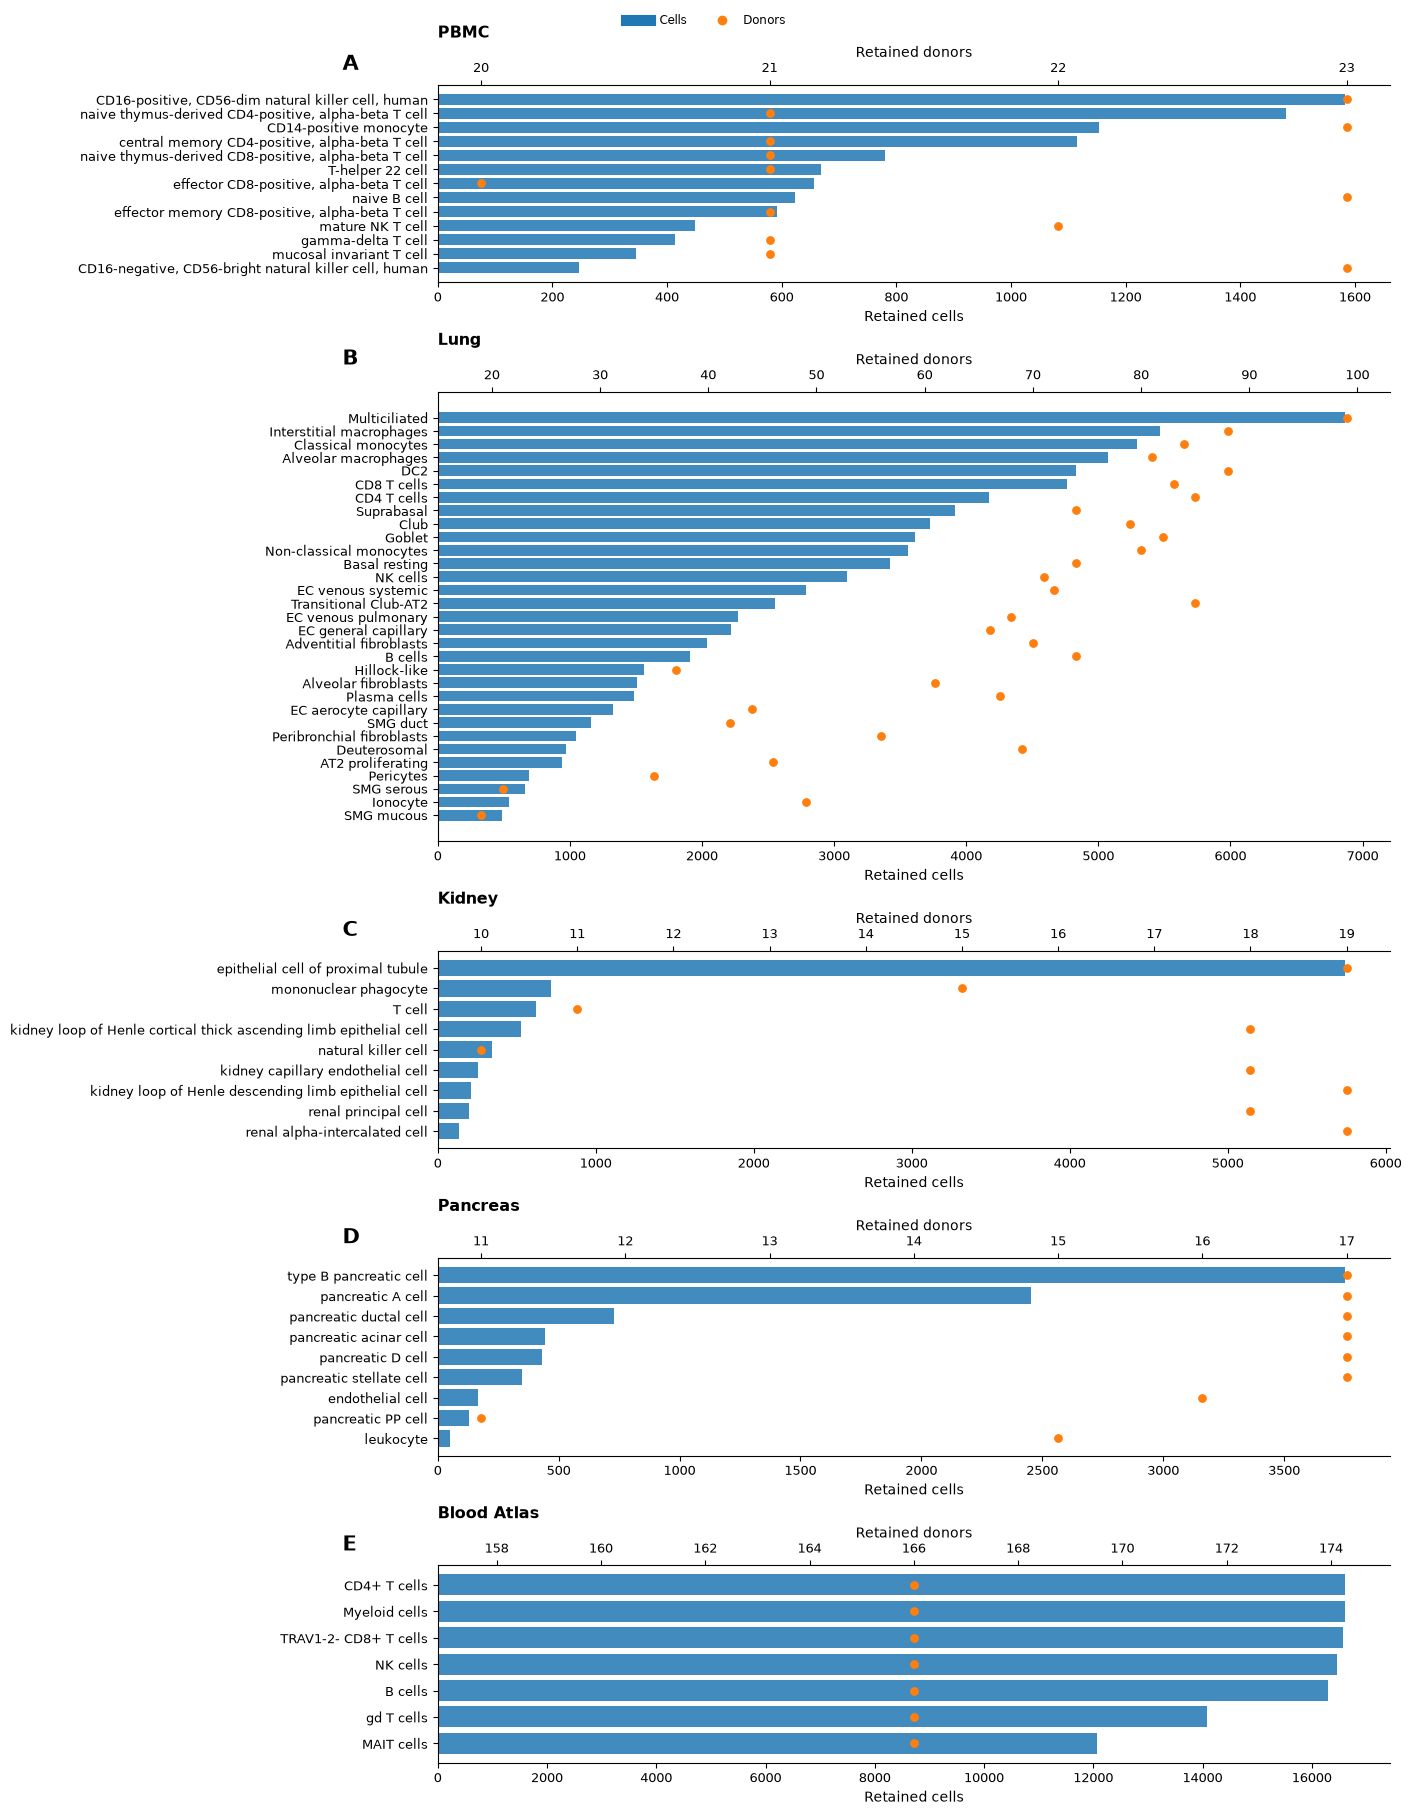

In [19]:
# ============================================================
# Figure S1 — Benchmark population and cell-type support
# ============================================================

from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

support_tables = {}

for dataset, info in DATASETS.items():
    adata = ad.read_h5ad(info["adata"], backed="r")

    obs = pd.DataFrame({
        "cell_type": adata.obs[info["celltype_col"]].astype(str),
        "donor": adata.obs[info["donor_col"]].astype(str),
    })

    support = (
        obs.groupby("cell_type", observed=True)
        .agg(
            n_cells=("cell_type", "size"),
            n_donors=("donor", "nunique"),
        )
        .sort_values("n_cells", ascending=False)
    )

    support_tables[dataset] = support

    if hasattr(adata, "file") and adata.file is not None:
        adata.file.close()


height_ratios = [
    max(3.0, 0.22 * len(support_tables[d]))
    for d in DATASETS
]

fig = plt.figure(
    figsize=(14, sum(height_ratios) * 0.95),
    layout="constrained",
)

gs = fig.add_gridspec(
    len(DATASETS),
    1,
    height_ratios=height_ratios,
)

legend_handles = [
    Line2D(
        [0], [0],
        color=BLUE,
        linewidth=8,
        label="Cells",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=ORANGE,
        markersize=6,
        label="Donors",
    ),
]

panel_letters = list("ABCDE")

for row, dataset in enumerate(DATASETS):
    ax = fig.add_subplot(gs[row, 0])
    support = support_tables[dataset]

    y = np.arange(len(support))

    # --------------------
    # Retained cells
    # --------------------
    ax.barh(
        y,
        support["n_cells"],
        color=BLUE,
        alpha=0.85,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(support.index)
    ax.invert_yaxis()

    ax.set_xlabel("Retained cells")

    # Keep dataset name as the panel title
    ax.set_title(
        dataset,
        loc="left",
        fontweight="bold",
    )

    clean_axis(ax)

    # --------------------
    # Retained donors
    # --------------------
    ax2 = ax.twiny()

    ax2.scatter(
        support["n_donors"],
        y,
        color=ORANGE,
        s=28,
        zorder=3,
    )

    ax2.set_xlabel("Retained donors")

    # Integer-only donor-axis ticks
    ax2.xaxis.set_major_locator(
        MaxNLocator(integer=True)
    )

    ax2.spines["bottom"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)

    # --------------------
    # Panel label
    # --------------------
    panel_letter(
        ax,
        panel_letters[row],
        x=-0.10,
        y=1.05,
    )


# --------------------
# Figure-level legend
# --------------------
fig.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
)


# fig.savefig(
#     FIG_DIR / "figure_S1_population_support.png",
#     dpi=300,
#     bbox_inches="tight",
# )
# fig.savefig(
#     FIG_DIR / "figure_S1_population_support.pdf",
#     bbox_inches="tight",
# )

plt.show()

Figure S2: cell-type UMAPs

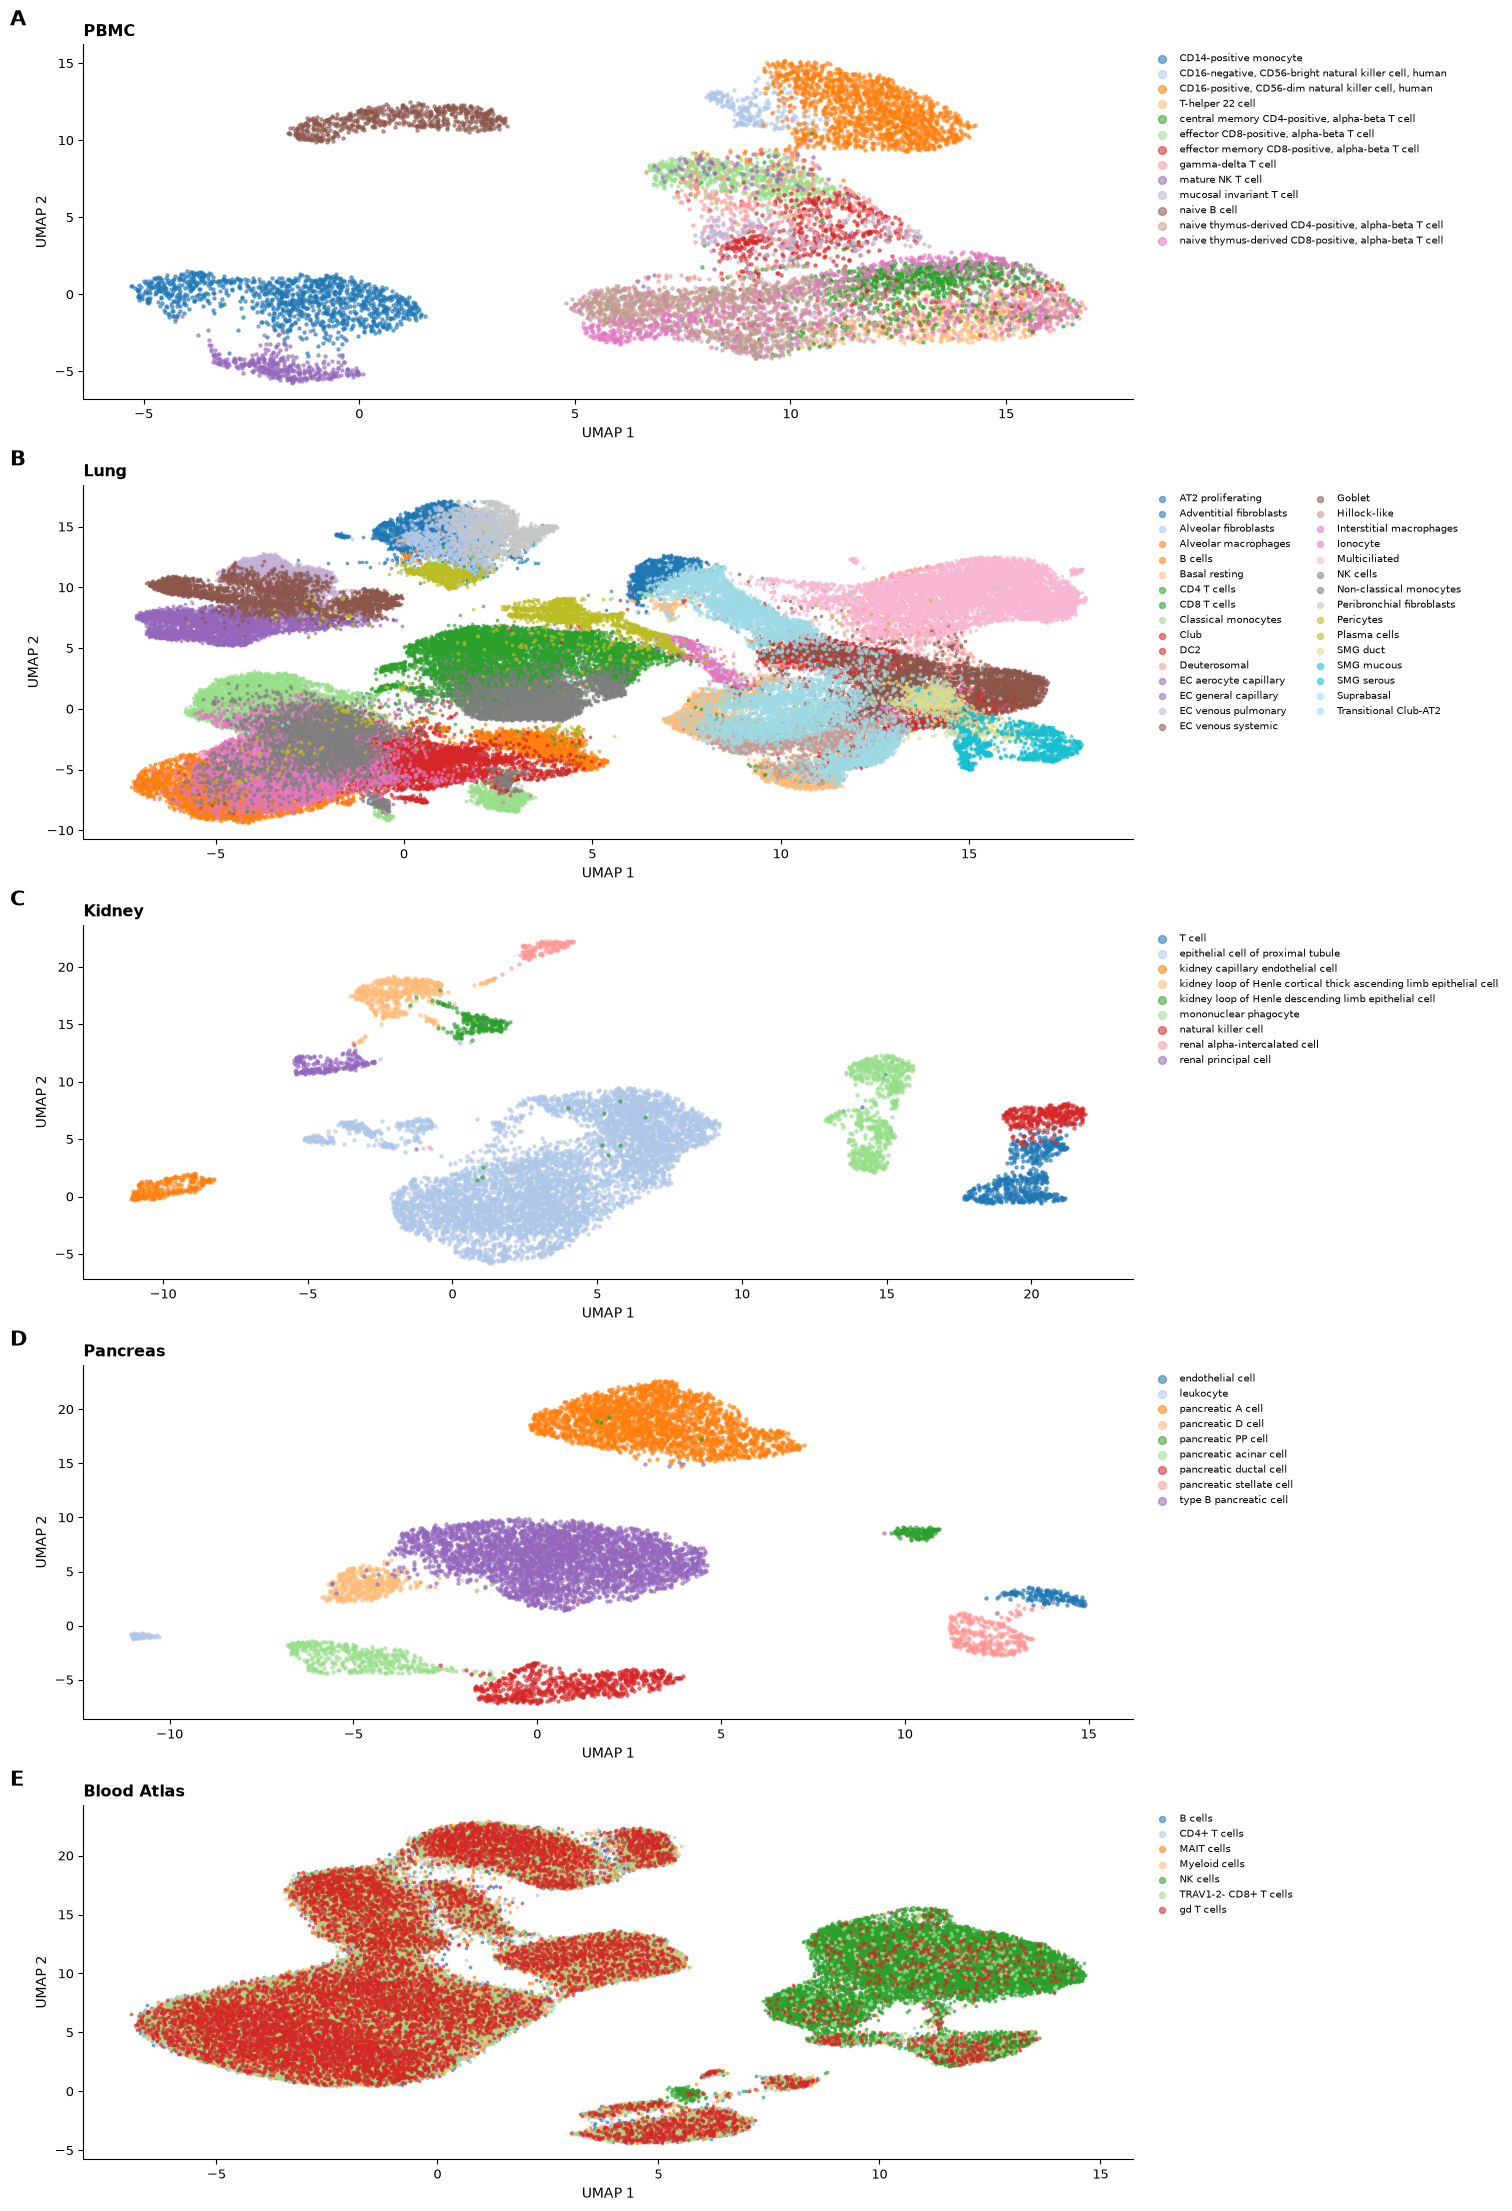

In [20]:
# ============================================================
# Figure S2 — Cell-type UMAPs
# ============================================================

fig, axes = plt.subplots(
    len(DATASETS),
    1,
    figsize=(15, 22),
    layout="constrained",
)

# In case len(DATASETS) == 1
if len(DATASETS) == 1:
    axes = [axes]

panel_letters = list("ABCDE")

for i, (ax, (dataset, info)) in enumerate(zip(axes, DATASETS.items())):
    coords = get_or_make_umap(
        dataset,
        [info["celltype_col"]],
    )

    col = info["celltype_col"]
    categories = sorted(coords[col].dropna().astype(str).unique())
    cmap = plt.get_cmap("tab20", max(20, len(categories)))

    for j, label in enumerate(categories):
        sub = coords[coords[col].astype(str).eq(label)]
        ax.scatter(
            sub["UMAP1"],
            sub["UMAP2"],
            s=3 if len(coords) > 50000 else 5,
            alpha=0.55,
            label=label,
            color=cmap(j),
            rasterized=True,
        )

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(dataset, loc="left", fontweight="bold")

    ncol = 2 if len(categories) > 16 else 1
    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        fontsize=7,
        markerscale=2.5,
        ncol=ncol,
    )

    clean_axis(ax)

    panel_letter(
        ax,
        panel_letters[i],
        x=-0.07,
        y=1.04,
    )


# fig.savefig(FIG_DIR / "figure_S2_celltype_umaps.png", dpi=300, bbox_inches="tight")
# fig.savefig(FIG_DIR / "figure_S2_celltype_umaps.pdf", bbox_inches="tight")

plt.show()

Figure S3: Technical/Source UMAPs

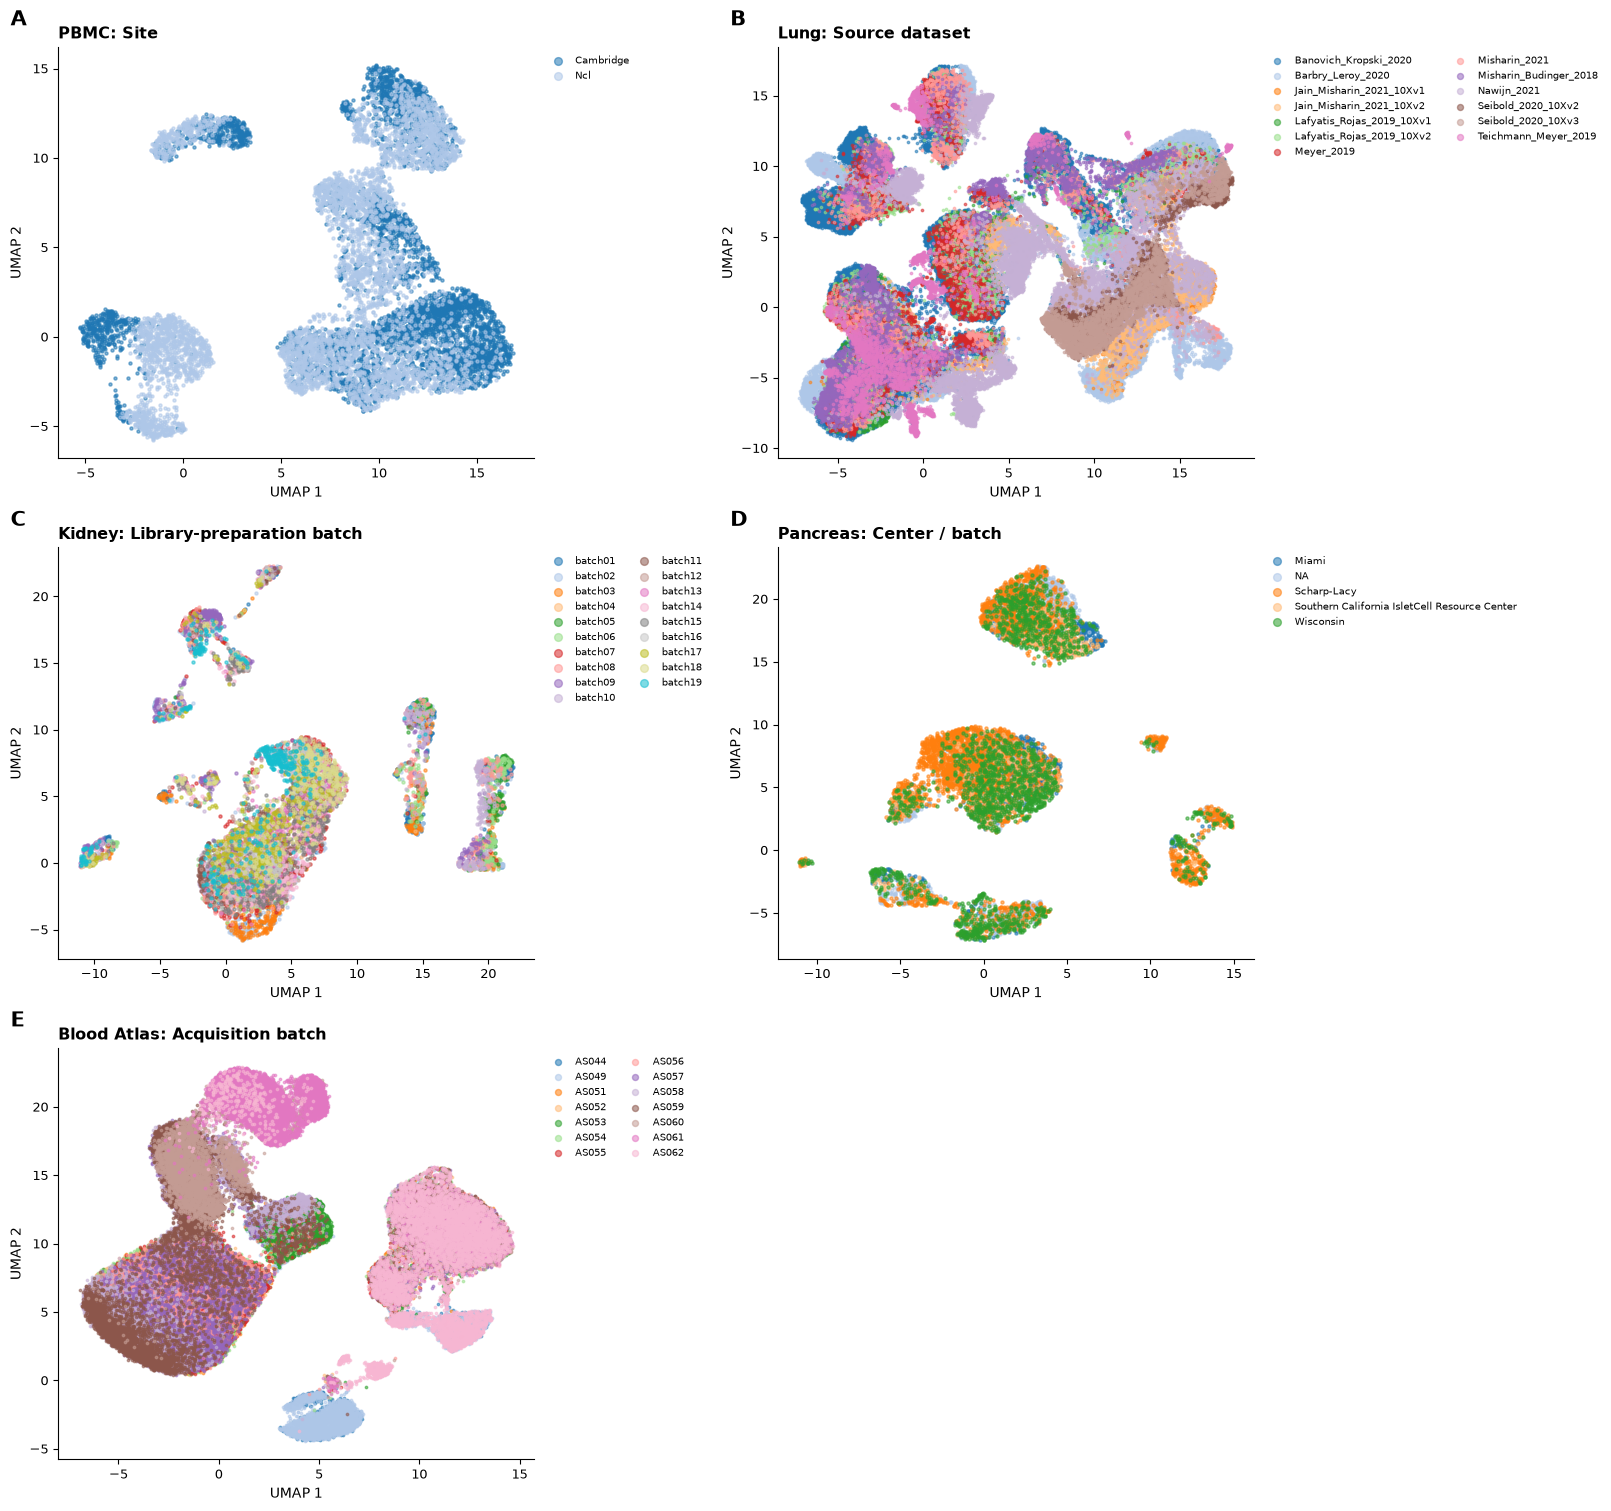

In [21]:
# ============================================================
# Figure S3 — Technical/source UMAPs
# ============================================================

import math

n_panels = len(DATASETS)
ncols = 2
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 5 * nrows),
    layout="constrained",
)

axes = np.atleast_1d(axes).ravel()
panel_letters = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

for i, ((dataset, info), ax) in enumerate(zip(DATASETS.items(), axes)):
    technical_col = choose_existing_column(
        info["adata"],
        info["technical_candidates"],
    )

    if technical_col is None:
        ax.axis("off")
        ax.text(
            0.5,
            0.5,
            f"{dataset}\nNo technical/source column found",
            ha="center",
            va="center",
        )
        panel_letter(ax, panel_letters[i], x=-0.10, y=1.04)
        continue

    coords = get_or_make_umap(
        dataset,
        [technical_col],
    )

    categories = sorted(coords[technical_col].dropna().astype(str).unique())
    cmap = plt.get_cmap("tab20", max(20, len(categories)))

    for j, label in enumerate(categories):
        sub = coords[coords[technical_col].astype(str).eq(label)]
        ax.scatter(
            sub["UMAP1"],
            sub["UMAP2"],
            s=3 if len(coords) > 50000 else 5,
            alpha=0.55,
            label=label,
            color=cmap(j),
            rasterized=True,
        )

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(
        f"{dataset}: {info['technical_label']}",
        loc="left",
        fontweight="bold",
    )

    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        fontsize=7,
        markerscale=2.5,
        ncol=1 if len(categories) <= 10 else 2,
    )

    clean_axis(ax)
    panel_letter(ax, panel_letters[i], x=-0.10, y=1.04)

# Turn off any unused axes
for ax in axes[n_panels:]:
    ax.axis("off")

# fig.savefig(FIG_DIR / "figure_S3_technical_umaps.png", dpi=300, bbox_inches="tight")
# fig.savefig(FIG_DIR / "figure_S3_technical_umaps.pdf", bbox_inches="tight")

plt.show()

Figure S4: PBMC Cross-site transfer

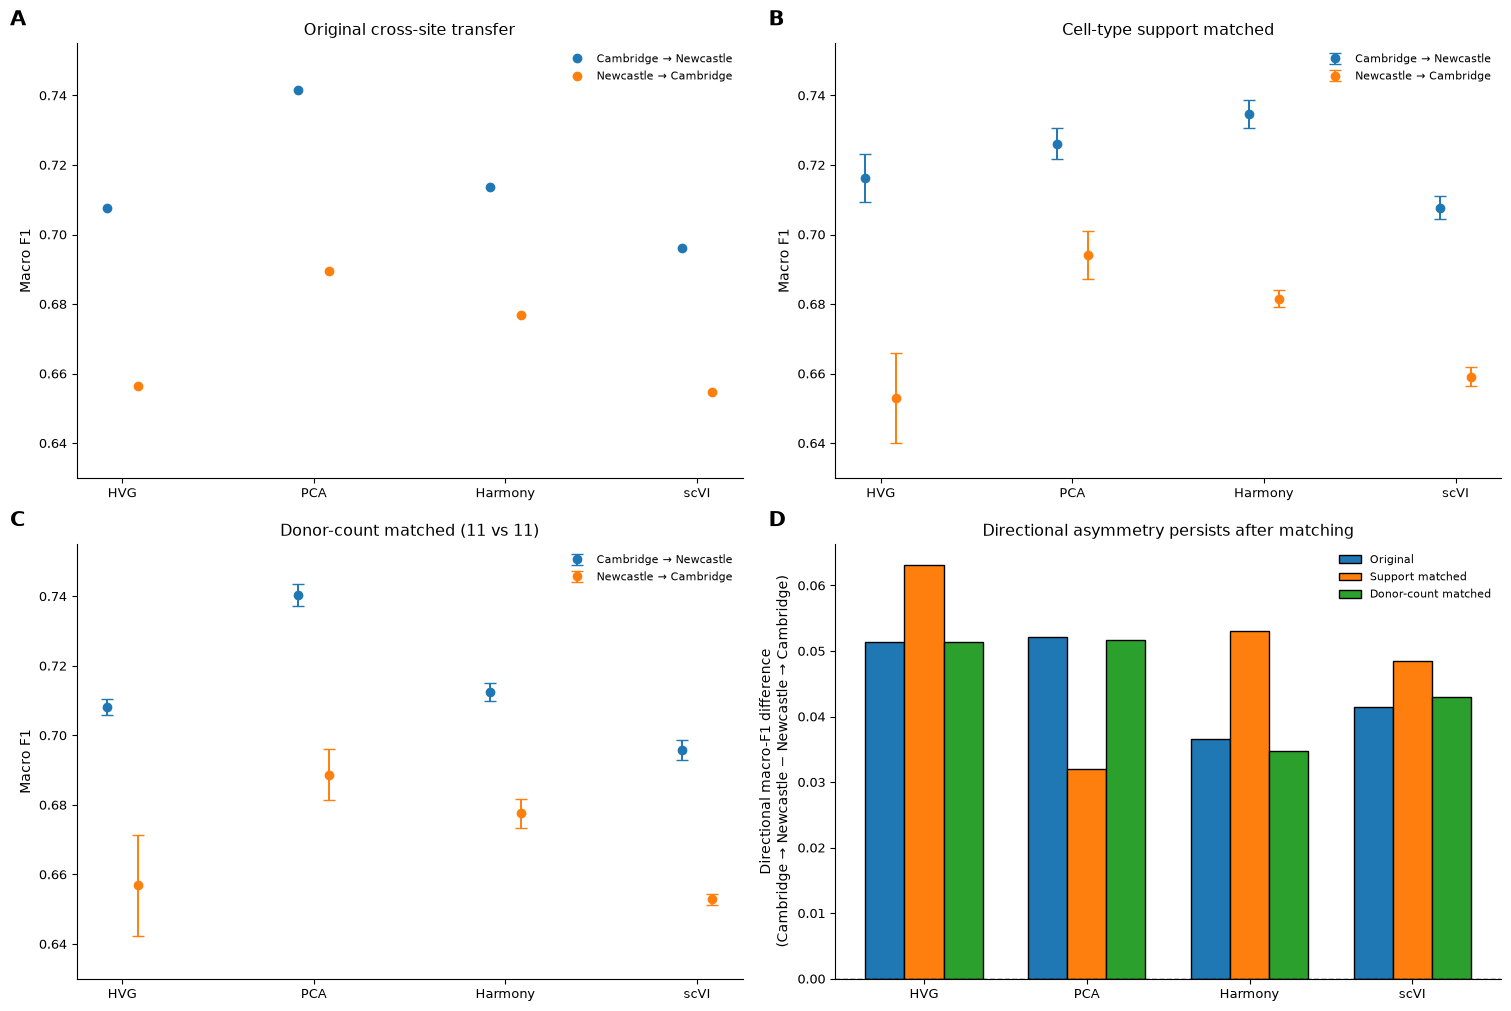

In [22]:
# ============================================================
# Figure S4 — PBMC cross-site transfer diagnostics
# ============================================================

TRANSFER_DIR = (
    REPO_ROOT
    / "results/pbmc_no_batch/group_transfer/Cambridge_vs_Ncl"
)

DIAG_DIR = TRANSFER_DIR / "diagnostics"

original = pd.read_csv(
    TRANSFER_DIR / "group_transfer_summary.csv"
)

support = pd.read_csv(
    DIAG_DIR / "support_matched_transfer_summary.csv"
)

donor_match = pd.read_csv(
    DIAG_DIR / "donor_count_matched_transfer_summary.csv"
)

gap = pd.read_csv(
    DIAG_DIR / "transfer_direction_gap_comparison.csv"
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    layout="constrained",
)

rep_order = [
    r for r in REP_ORDER
    if r in set(original["representation"])
]

x = np.arange(len(rep_order))

direction_order = [
    "Cambridge_to_Ncl",
    "Ncl_to_Cambridge",
]

direction_labels = {
    "Cambridge_to_Ncl": "Cambridge → Newcastle",
    "Ncl_to_Cambridge": "Newcastle → Cambridge",
}

offsets = [-0.08, 0.08]

# Use the same y-axis range for A–C
transfer_ylim = (0.63, 0.755)


# ------------------------------------------------------------
# A. Original transfer
# ------------------------------------------------------------

ax = axes[0, 0]

for j, direction in enumerate(direction_order):
    sub = (
        original[original["direction"].eq(direction)]
        .set_index("representation")
        .reindex(rep_order)
    )

    ax.plot(
        x + offsets[j],
        sub["macro_f1"],
        linestyle="None",
        marker="o",
        markersize=6,
        label=direction_labels[direction],
    )

ax.set_xticks(
    x,
    [REP_LABELS[r] for r in rep_order],
)
ax.set_ylabel("Macro F1")
ax.set_ylim(*transfer_ylim)
ax.set_title("Original cross-site transfer")
ax.legend(frameon=False, fontsize=8)

clean_axis(ax)
panel_letter(ax, "A", x=-0.10, y=1.03)


# ------------------------------------------------------------
# B. Cell-type support-matched transfer
# ------------------------------------------------------------

ax = axes[0, 1]

for j, direction in enumerate(direction_order):
    sub = (
        support[support["direction"].eq(direction)]
        .set_index("representation")
        .reindex(rep_order)
    )

    ax.errorbar(
        x + offsets[j],
        sub["macro_f1_mean"],
        yerr=sub["macro_f1_std"],
        fmt="o",
        markersize=6,
        capsize=4,
        linewidth=1.4,
        label=direction_labels[direction],
    )

ax.set_xticks(
    x,
    [REP_LABELS[r] for r in rep_order],
)
ax.set_ylabel("Macro F1")
ax.set_ylim(*transfer_ylim)
ax.set_title("Cell-type support matched")
ax.legend(frameon=False, fontsize=8)

clean_axis(ax)
panel_letter(ax, "B", x=-0.10, y=1.03)


# ------------------------------------------------------------
# C. Donor-count matched transfer
# ------------------------------------------------------------

ax = axes[1, 0]

for j, direction in enumerate(direction_order):
    sub = (
        donor_match[donor_match["direction"].eq(direction)]
        .set_index("representation")
        .reindex(rep_order)
    )

    ax.errorbar(
        x + offsets[j],
        sub["macro_f1_mean"],
        yerr=sub["macro_f1_std"],
        fmt="o",
        markersize=6,
        capsize=4,
        linewidth=1.4,
        label=direction_labels[direction],
    )

ax.set_xticks(
    x,
    [REP_LABELS[r] for r in rep_order],
)
ax.set_ylabel("Macro F1")
ax.set_ylim(*transfer_ylim)
ax.set_title("Donor-count matched (11 vs 11)")
ax.legend(frameon=False, fontsize=8)

clean_axis(ax)
panel_letter(ax, "C", x=-0.10, y=1.03)


# ------------------------------------------------------------
# D. Directional-gap comparison
# ------------------------------------------------------------

ax = axes[1, 1]

analysis_order = [
    "original",
    "support matched",
    "donor-count matched",
]

analysis_labels = {
    "original": "Original",
    "support matched": "Support matched",
    "donor-count matched": "Donor-count matched",
}

width = 0.24

for j, analysis in enumerate(analysis_order):
    sub = (
        gap[gap["analysis"].eq(analysis)]
        .set_index("representation")
        .reindex(rep_order)
    )

    ax.bar(
        x + (j - 1) * width,
        sub[
            "direction_gap_Cambridge_to_Ncl_minus_reverse"
        ],
        width=width,
        label=analysis_labels[analysis],
        edgecolor="black",
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    color="black",
)

ax.set_xticks(
    x,
    [REP_LABELS[r] for r in rep_order],
)

ax.set_ylabel(
    "Directional macro-F1 difference\n"
    "(Cambridge → Newcastle − Newcastle → Cambridge)"
)

ax.set_title(
    "Directional asymmetry persists after matching"
)

ax.legend(
    frameon=False,
    fontsize=8,
)

clean_axis(ax)
panel_letter(ax, "D", x=-0.10, y=1.03)


# fig.savefig(
#     FIG_DIR / "figure_S4_pbmc_transfer.png",
#     dpi=300,
#     bbox_inches="tight",
# )
# fig.savefig(
#     FIG_DIR / "figure_S4_pbmc_transfer.pdf",
#     bbox_inches="tight",
# )

plt.show()

Figure S5: Synthetic floor-control

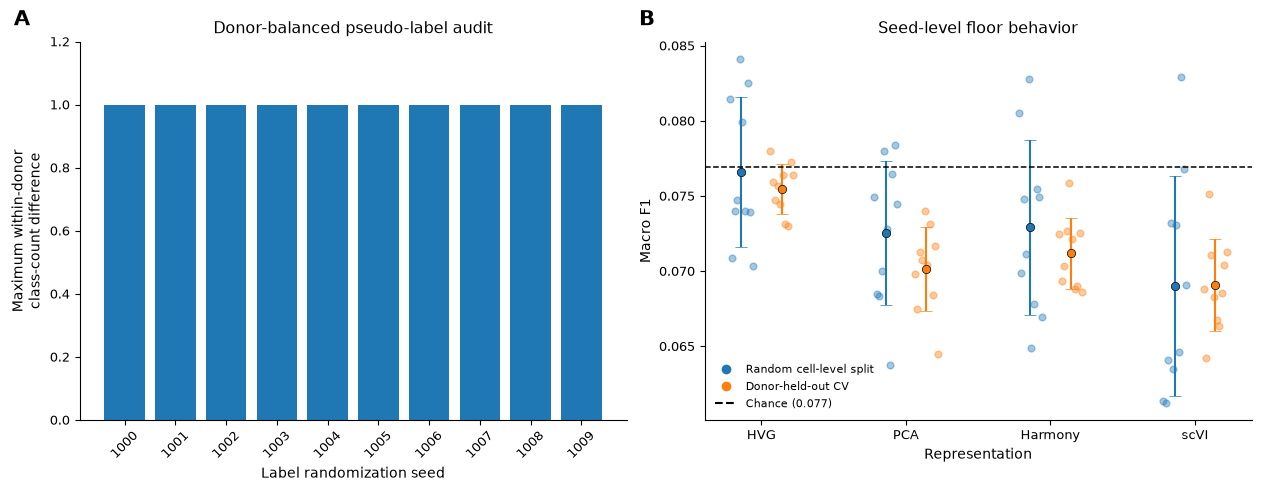

In [23]:
# ============================================================
# Figure S5 — Synthetic floor-control audits
# ============================================================

SYN_DIR = REPO_ROOT / "results/synthetic_floor"

replicates = pd.read_csv(
    SYN_DIR / "null_control_replicates.csv"
)

balance = pd.read_csv(
    SYN_DIR / "null_label_balance.csv"
)

with open(
    SYN_DIR / "config.json",
    "r",
    encoding="utf-8",
) as handle:
    config = json.load(handle)

donor_col = config["donor_col"]
chance = float(config["chance_macro_f1"])


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    layout="constrained",
)


# ------------------------------------------------------------
# A. Maximum within-donor pseudo-label imbalance by seed
# ------------------------------------------------------------

ax = axes[0]

donor_seed_imbalance = (
    balance
    .groupby(["label_seed", donor_col])["n_cells"]
    .agg(lambda x: x.max() - x.min())
    .reset_index(name="max_minus_min")
)

seed_max = (
    donor_seed_imbalance
    .groupby("label_seed")["max_minus_min"]
    .max()
)

ax.bar(
    seed_max.index.astype(str),
    seed_max.values,
    color=BLUE,
)

ax.set_xlabel("Label randomization seed")
ax.set_ylabel(
    "Maximum within-donor\nclass-count difference"
)
ax.set_title(
    "Donor-balanced pseudo-label audit"
)

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.set_ylim(
    0,
    max(1.2, seed_max.max() + 0.2),
)

clean_axis(ax)
panel_letter(
    ax,
    "A",
    x=-0.12,
    y=1.03,
)


# ------------------------------------------------------------
# B. Seed-level absolute performance stays near chance
# ------------------------------------------------------------

ax = axes[1]

rep_order = [
    r for r in REP_ORDER
    if r in set(replicates["representation"])
]

scheme_specs = [
    (
        "random_split",
        BLUE,
        "Random cell-level split",
    ),
    (
        "donor_cv",
        ORANGE,
        "Donor-held-out CV",
    ),
]

positions = np.arange(len(rep_order))

for s_idx, (scheme, color, label) in enumerate(scheme_specs):

    for i, rep in enumerate(rep_order):

        values = (
            replicates.loc[
                replicates["scheme"].eq(scheme)
                & replicates["representation"].eq(rep),
                "macro_f1_mean",
            ]
            .dropna()
            .to_numpy()
        )

        center = (
            positions[i]
            + (-0.14 if s_idx == 0 else 0.14)
        )

        offsets = np.linspace(
            -0.08,
            0.08,
            len(values),
        )

        ax.scatter(
            center + offsets,
            values,
            color=color,
            alpha=0.40,
            s=24,
        )

        ax.errorbar(
            center,
            values.mean(),
            yerr=values.std(ddof=1),
            fmt="o",
            color=color,
            markeredgecolor="black",
            markeredgewidth=0.5,
            capsize=4,
            markersize=6,
        )


ax.axhline(
    chance,
    color="black",
    linestyle="--",
    linewidth=1.1,
)

ax.set_xticks(
    positions,
    [REP_LABELS[r] for r in rep_order],
)

ax.set_xlabel("Representation")
ax.set_ylabel("Macro F1")
ax.set_title(
    "Seed-level floor behavior"
)

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=BLUE,
        label="Random cell-level split",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=ORANGE,
        label="Donor-held-out CV",
    ),
    Line2D(
        [0], [0],
        linestyle="--",
        color="black",
        label=f"Chance ({chance:.3f})",
    ),
]

ax.legend(
    handles=handles,
    frameon=False,
    fontsize=8,
)

clean_axis(ax)
panel_letter(
    ax,
    "B",
    x=-0.12,
    y=1.03,
)


# fig.savefig(
#     FIG_DIR / "figure_S5_synthetic_audits.png",
#     dpi=300,
#     bbox_inches="tight",
# )
# fig.savefig(
#     FIG_DIR / "figure_S5_synthetic_audits.pdf",
#     bbox_inches="tight",
# )

plt.show()